<a href="https://colab.research.google.com/github/AlanAmaro13/3d-classification/blob/main/1_TestModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3D Classification Model: Test.

## Used libraries

To plot the fossils we use PaleoVox; we install Open3D.

In [ ]:
! pip install open3d

In [ ]:
import seaborn as sns

To optimize the AI pipeline let's use AmaroX, a _craft-made library_ for DeepLearning.

In [ ]:
import sys
import os

# Add the AmaroXI folder to Python path
sys.path.append('/content/drive/MyDrive/cellularAutomata/3dClassification')

In [ ]:
! pip install python-telegram-bot

In [ ]:
from AmaroXI.AmaroX.ai_functions import *
from AmaroXI.AmaroX.Convolutional import *
from AmaroXI.AmaroX.data_manipulation import *
from AmaroXI.AmaroX.utilities import *
from AmaroXI.AmaroX.DNN import *

In [ ]:
from paleovox import *

## Load Data

Let's load the deformed cubes and spheres from before:

In [ ]:
cubes = np.load('/content/drive/MyDrive/cellularAutomata/3dClassification/database/cubes.npy')
cubes.shape

(10000, 32, 32, 32)

And let's design their labels:

In [ ]:
cubes_labels = int(cubes.shape[0]) * [0]
cubes_labels = np.array(cubes_labels)
cubes_labels.shape

(10000,)

In [ ]:
cubes_labels[0]

np.int64(0)

In [ ]:
spheres = np.load('/content/drive/MyDrive/cellularAutomata/3dClassification/database/spheres.npy')
spheres.shape

(10000, 32, 32, 32)

In [ ]:
spheres_labels = int(spheres.shape[0]) * [1]
spheres_labels = np.array(spheres_labels)
spheres_labels.shape

(10000,)

In [ ]:
spheres_labels[0]

np.int64(1)

Then we need to combine them and add a channel dimension:

In [ ]:
x_data = np.expand_dims( np.concatenate((cubes, spheres), axis=0), axis = -1 )
x_data.shape

(20000, 32, 32, 32, 1)

In [ ]:
del spheres, cubes

In [ ]:
y_data = np.expand_dims( np.concatenate((cubes_labels, spheres_labels), axis=0), axis = -1 )
y_data.shape

(20000, 1)

We need to organize them randomly, to perform that operations let's grab the indexes and use them.

In [ ]:
indices = np.random.permutation(len(y_data))
x_data = x_data[indices]
y_data = y_data[indices]

Let's consider 80% of the data for training, 10% for testing and 10% for validation.

In [ ]:
x_train = x_data[:int(0.8*len(y_data))]
y_train = y_data[:int(0.8*len(y_data))]

x_val = x_data[int(0.8*len(y_data)) : int(0.9*len(y_data))  ]
y_val = y_data[int(0.8*len(y_data)) : int(0.9*len(y_data)) ]

x_test = x_data[ int(0.9*len(y_data)) :]
y_test = y_data[ int(0.9*len(y_data)) :]

In [ ]:
x_train.shape, x_val.shape, x_test.shape

((16000, 32, 32, 32, 1), (2000, 32, 32, 32, 1), (2000, 32, 32, 32, 1))

In [ ]:
y_train.shape, y_val.shape, y_test.shape

((16000, 1), (2000, 1), (2000, 1))

## Visualization

In [ ]:
plot_voxels(x_train[0])

## Seaborn

This are just plotting parameters for seaborn.

In [ ]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
   "figure.dpi": 300,           # Default DPI for new figures
   "savefig.dpi": 300,          # DPI when saving figures

   # Font settings
   "font.family": "sans-serif",     # Universal font family
   "font.size": 11,                   # Base font size

   # Title and label sizes
   "axes.titlesize": 16,             # Axis title size
   "axes.titleweight": "bold",       # Axis title weight
   "axes.labelsize": 14,             # Axis label size
   "axes.labelweight": "semibold",   # Axis label weight

   # -------------------------------------------------

   # Tick LABEL sizes (text next to ticks)
   "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
   "ytick.labelsize": 11,       # Size of y-axis tick labels

   # Tick MARK sizes (physical marks on axes)
   "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
   "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

   # Additional tick parameters you might want to use:
   "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
   "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

   # Tick WIDTH (thickness)
   "xtick.major.width": 1,      # Width/Thickness of major ticks
   "ytick.major.width": 1,      # Width/Thickness of major ticks

   # Tick PADDING (distance from label to tick)
   "xtick.major.pad": 3.5,      # Padding between x-tick and label
   "ytick.major.pad": 3.5,      # Padding between y-tick and label

   # Tick DIRECTIONS
   "xtick.direction": "out",    # "in", "out", or "inout"
   "ytick.direction": "out",    # Points outward from axis

   # Tick COLORS
   "xtick.color": "black",      # Color of x-axis ticks and labels
   "ytick.color": "black",      # Color of y-axis ticks and labels

   # MINOR ticks (for more granular scales)
   "xtick.minor.visible": False,  # Show minor x-ticks
   "ytick.minor.visible": False,  # Show minor y-ticks

   # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
   "xtick.top": False,          # Show ticks on top of plot
   "xtick.bottom": True,        # Show ticks on bottom (default: True)
   "ytick.left": True,          # Show ticks on left (default: True)
   "ytick.right": False,        # Show ticks on right

   # ---------------------------------

   # Legend
   "legend.fontsize": 10,
   "legend.title_fontsize": 12,
   "legend.framealpha":0.9,

   # Figure title (for suptitle)
   "figure.titlesize": 18,
   "figure.titleweight": "bold",

   # ----------------------------------

   # Figure border
   #"figure.edgecolor": "black",
   #"figure.frameon": True,
   #"figure.linewidth": 2.0,

   # Axes borders (spines)
   "axes.linewidth": 1.0,           # Width of axis lines
   "axes.edgecolor": "black",       # Color of axis lines

   # Individual spine control via rcParams
   "axes.spines.top": True,
   "axes.spines.bottom": True,
   "axes.spines.left": True,
   "axes.spines.right": True,

   # ----------------------------
   # Patch properties (for histograms, bars, kde fills, etc.)
   "patch.linewidth": 1.5,           # Default linewidth for patches
   "patch.edgecolor": "black",       # Default edge color
   "patch.facecolor": "blue",        # Default fill color (careful with this!)
   "patch.force_edgecolor": True,    # Always show edges

})

## GPU Allocation

Let's use GPU for accelerate the training process.

In [ ]:
get_gpu(0)

## Paths

Let's set the paths to storage our model and images.

In [ ]:
folder_path = '/content/drive/MyDrive/cellularAutomata/3dClassification/models'

In [ ]:
name = '3dClassificationTest'

In [ ]:
final_path = os.path.join(folder_path, name)
final_path

'/content/drive/MyDrive/cellularAutomata/3dClassification/models/3dClassificationTest'

In [ ]:
images_path = os.path.join(final_path, 'images')
images_path

'/content/drive/MyDrive/cellularAutomata/3dClassification/models/3dClassificationTest/images'

## Callbacks

In order to get the best possible model let's use Callbacks over the loss function.

In [ ]:
def standard_callbacks(folder_name: str, patiences: list, folder_path: str = '../Models',
                       monitor: str = 'val_metric_accuracy', flow_direction = 'max') -> tuple:
    '''
    Description:
        This functions returns the usual callbacks used during training, such as EarlyStopping, ReduceLearningRate, Checkpoint and CSV Logger.
        It also generates the folder in which all the data will be storage.

        By default we consider the next values:
            * EarlyStopping restores the best weights
            * The reduce on the lr is by 0.8 until we reached 1e-6
            * Checkpoint only saves the best model each epoch

    Args:
        folder_name (str): Refers to folder's name
        patiences (list): Refers to the patience values for EarlyStopping and ReduceOnLR
        folder_path (str): Refers to path where the folder will be created
        monitor (str): Variable to be monitored, by default corresponds to 'val_metric_accuracy'
        patiences (list): Refers to the patiences values for EarlyStopping,

    Return: tuple containing
        EarlyStopping (early)
        ReduceLearningRate (reduce_lr)
        CheckPoint (check)
        CSVlogger (csv_logger)
    '''

    i_choice = 0

    _path = folder_path + '/' + folder_name
    os.makedirs(_path, exist_ok = True) # Make the dir

    _main = (
        tf.keras.callbacks.EarlyStopping(
            monitor = monitor[i_choice],
            patience = patiences[0],
            restore_best_weights=True,
            mode = flow_direction[i_choice]),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor[i_choice],
            factor=0.8,
            patience= patiences[1],
            min_lr=1e-6 ),

          [
           tf.keras.callbacks.ModelCheckpoint(
            filepath=  os.path.join(_path, '{}_{}.keras'.format( mont, flow) ),
            save_weights_only=False,
            monitor=mont,
            mode= flow,
            save_freq = 'epoch',
            save_best_only=True)  for mont, flow in zip(monitor, flow_direction)
           ],

            keras.callbacks.CSVLogger( os.path.join(_path, 'training.log') )
           )

    return tuple(item for sublist in _main
                for item in (sublist if isinstance(sublist, list) else [sublist]))

In [ ]:
callbacks = standard_callbacks(
    folder_name=name,
    folder_path=folder_path,
    patiences=[1000, 1000],  # Adjusted patience values
    monitor=[
        'val_loss',                          # Validation loss (always available)
    ],
    flow_direction=[
        'min',  # loss - minimize
    ]
)

In [ ]:
callbacks

(<keras.src.callbacks.early_stopping.EarlyStopping at 0x7cf03d0487a0>,
 <keras.src.callbacks.csv_logger.CSVLogger at 0x7cf10a59a030>)

## Backbone Functions

This is our custom CNN modified for 3D classification.

In [ ]:
def G_ConvBlock_3D(inputs: tf.Tensor, filters: int, kernel:list, act_func: str, pad_type:str,
                pool:list, stride:list, WIC:str, WRC, stride_conv: list = (1,1,1), pool_op = 'AP'):
    '''
    Args:
        inputs (Tensor): The input information for the Conv2D
        filters (int): The number of filters in the Convolutional
        kernel (list): kernel size in the Conv
        stride_conv (list): strides in the Conv
        WIC (str): Kernel Initializer in the Conv
        WRC (str): Kernel Regulatier in the Conv
        act_func (str): Activation Function
        pool (list): pool size in the pooling layer
        stride (list): stride size in the pooling layer

    Flux:
        Conv->BN->Activation->AP

    Observations:
        1. The Convolutionals preserves dimension. When padding="same" and strides=(1,1,1), the output has the same size as the input
        2. Before is the BatchNormalization and after the Activation.
        3. The dimension after the Conv is
            (input_shape - pool_size + 1) / strides)

    Test:



    Pooling Operations:
    Downsamples the input representation by taking the maximum value over a spatial window of size pool_size.
    The window is shifted by strides.

    The resulting output when using the "valid" padding option has a shape of: output_shape = (input_shape - pool_size + 1) / strides).

    The resulting output shape when using the "same" padding option is: output_shape = input_shape / strides
    '''

    Conv = keras.layers.Conv3D(
        filters = filters,
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(inputs)

    BN = keras.layers.BatchNormalization()(Conv)
    Act = keras.layers.Activation(activation = act_func)(BN)

    if pool_op == 'AP':
        AP = keras.layers.AveragePooling3D(
            pool_size = pool,
            strides = stride,
            padding = pad_type
            )(Act)
    elif pool_op == 'MP':
        AP = keras.layers.MaxPooling3D(
        pool_size = pool,
        strides = stride,
        padding = pad_type
        )(Act)

    elif pool_op == None:
        AP = Act

    return AP

# ---------- Convolutional Neural Network

def CNN_3D(inputs: tf.Tensor, filters:list, kernel:list, pad_type:str, pool:list, stride:list, nodes: list, DP: int, n_final: int,
       WIC:str, WRC, stride_conv:list = (1,1,1), pool_op:str= 'AP', act_func: str = 'leaky_relu',
        final_act_func: str = 'softmax', WI: str = 'he_normal', L1: float = 0.0, L2: float = 0.0, use_bias: bool = False,
       act_func_conv:str = 'leaky_relu'):
    '''
    Desc:
        This function is used to create a Convolutional Neural Network. It provides a easy interface to perform Hyper-parameters research.

        The initial component is the input, this is usually a keras.layers.Input((n,1)), where n is the dimension of the signal. To define
        the number of ConvBlock we used a list for the filters, each element in this list represents the filter for each ConvBlock. We also
        provide the use the ability to change the kernel size depending of the ConvBlock (if you want to set a fix kernel size just use
        the operation Deep*[kernel_size]).

        The activation function for the convolutional is set to LeakyReLU (better results might be obtained with a SReLU). An important note
        is:

        * The Convolutional section preverves the dimensionality. This means that all the reduction is performed by the Pooling Operations.
        This also implies that the padding in the Conv is set to 'same' and stride_conv=(1,1).

        The Pooling Operations are configured to be:
        * AP: Average Pooling
        * MP: Max Pooling
        It's easy to observe that a new pooling operation can be added without major problem. The parameters to reduce dimension are: pad_type,
        pool and stride, the final dimension is calculated as follows:

        - The resulting output when using the "valid" padding option has a shape of: output_shape = (input_shape - pool_size + 1) / strides).

        - The resulting output shape when using the "same" padding option is: output_shape = input_shape / strides

        WIC means Weight Initializer for the Convolutional. The best WIC is He Normal (or He Uniform, depending if the architecture has BachNorm),
        WRC means Weight Regularizer, I recommend the use of L1L2.

        This flux is repeated for each filter in filters. After the convolutional operations, a flatten operation is applied. Then we employ
        the G_Dense section. Here the input is the output flatten, the nodes are defined as a list, where each elements are the nodes in each
        hidden layer. WI means Weight initializer (again, I recommend use He Normal). For regularization I added Dropout (integer number
        represeting a porcentage), L1L2 (ElasticNet). The activation function inside the architecture might be different from the final, so I
        give that option (I use LeakyReLU for hiddden layers and ReLU for output). Finally, you can decide whether you want to use bias in the
        Dense Layers.

    Args:
        inputs (tf.Tensor): This is the Tensor input.
        filters (list): This list contains each filter for each convolutional block.
        kernel (list): This list contains the kernel size for each convolutional block.
        act_func (str): This is the activation function, I really recommed use a rectified operation, such as LeakyReLU, ReLU, PReLU, SRELU.

        -> These parameters are for the Pooling Operation.
        pad_type (str):
        pool (list):
        stride (list):

        WIC (str): This is the Weight Initializer for the Convolutional, I really recommend using He Normal (because the BatchNorm).
        WRC (KerasObject): This is the kernel regularizer, I really recommend using L1L2, varying the values.
        stride_conv (list): This is the stride for the Convolutional

        pool_op (str): This is the Pooling Operation.

    Returns:
        CNN Model

    Flux:
        ConvBlock -> ConvBlock -> ... -> Flatten -> G_Dense

    Example:
        modelo = CNN_3D(
            inputs = keras.layers.Input((32, 32, 32 ,1)),
            filters = [256, 128, 64],
            kernel = [(11, 11, 11), (5,5,5), (3,3,3)],
            pad_type = 'valid',
            pool = (4,4,4),
            stride = (4,4,4),
            nodes = [50, 25, 5],
            DP = 5,
            n_final = 1,
            WIC = 'he_normal',
            WRC = keras.regularizers.L1L2(l1 = 1e-6, l2 = 1e-6),
            final_act_func= 'relu',
            L1 = 1e-6,
            L2 = 1e-6,
            use_bias = True
        )
    '''

    _stage = G_ConvBlock_3D(
        inputs = inputs,
        filters = filters[0],
        kernel = kernel[0],
        act_func = act_func_conv,
        pad_type = pad_type,
        pool = pool,
        stride = stride,
        WIC = WIC,
        WRC = WRC,
        stride_conv=stride_conv,
        pool_op=pool_op
    )

    for i in range(len(filters[0:])):
        _stage = G_ConvBlock_3D(
            inputs = _stage,
            filters = filters[i],
            kernel = kernel[i],
            act_func = act_func_conv,
            pad_type = pad_type,
            pool = pool,
            stride = stride,
            WIC = WIC,
            WRC = WRC,
            stride_conv=stride_conv,
            pool_op=pool_op
        )

    _flatten = keras.layers.Flatten()(_stage)

    _dense = G_Dense(
        inputs = _flatten,
        nodes = nodes,
        DP = DP,
        n_final = n_final,
        act_func = act_func,
        final_act_func= final_act_func,
        WI = WI,
        L1 = L1,
        L2 = L2,
        use_bias = use_bias
    )

    return keras.models.Model(inputs = inputs, outputs = _dense)

## Seed

Let's fix a set for the weight initilization inside the network.

In [ ]:
seed = np.random.randint(2**32 - 1)
seed

2722226082

In [ ]:
keras.utils.set_random_seed(seed)

## Model

This is our CNN model used for Binary Classification of voxels. We have set the number of filters and nodes by hand.

In [ ]:
def CNN_Model():
  inputs = keras.layers.Input( ( 32, 32, 32, 1) )

  __CNN_3D = CNN_3D(
      inputs = inputs,
      filters = [25, 50, 100],
      kernel = [(8,8,8), (4,4,4), (2,2,2)],
      pad_type = 'valid',
      pool = (2,2,2),
      stride = (2,2,2),
      nodes = [50, 25],
      DP = 5,
      n_final = 1,
      WIC = 'he_normal',
      WRC = keras.regularizers.L1L2(l1 = 1e-6, l2 = 1e-6),
      final_act_func= 'sigmoid',
      L1 = 1e-6,
      L2 = 1e-6,
      use_bias = True
  )

  return __CNN_3D

In [ ]:
model_CNN = CNN_Model()

Let's compile the model; as loss function we are using binary crossentropy and to train the net we are using Adam.

In [ ]:
model_CNN.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss = "binary_crossentropy", #keras.losses.BinaryFocalCrossentropy(alpha = 0.75),
    metrics = [
        #keras.metrics.AUC(),
        #keras.metrics.Precision(),
        #keras.metrics.Recall(),
        #keras.metrics.CategoricalAccuracy(),
        #keras.metrics.SparseCategoricalAccuracy(),
        #keras.metrics.Accuracy()
        #keras.metrics.F1Score()
        ],
    jit_compile=False  # Critical for H100
)

In [ ]:
model_CNN.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 32, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 32, 32, 32, 25) │        12,825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32, 25) │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32, 25) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 16, 16, 16, 25) │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 16, 16, 16, 25) │       320,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 16, 25) │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 16, 25) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 8, 8, 8, 25)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 8, 8, 8, 50)    │        80,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 8, 50)    │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 8, 50)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 4, 4, 4, 50)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 4, 4, 4, 100)   │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 4, 100)   │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 4, 4, 4, 100)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_3             │ (None, 2, 2, 2, 100)   │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        40,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50)             │           20

 Total params: 495,451 (1.89 MB)

 Trainable params: 494,901 (1.89 MB)

 Non-trainable params: 550 (2.15 KB)

## Plot Model

This function will generate a plot of the model.

In [ ]:
def get_plot_model(model: keras.models.Model, folder_path:str ):
    '''
    Description:
        This functions does the plot of the model and save it into the give path.

    Args:
        model (keras.models.Model): This arg corresponds to the model function
        path (str): This path corresponds to the folder where the image will be storage

    Returns
        None
    '''

    keras.utils.plot_model(model,
                          to_file = folder_path + '/model.png',
                          show_shapes = True,
                          show_layer_names = True)

In [ ]:
get_plot_model(model_CNN, folder_path= final_path)

## Training

In [ ]:
def model_training(model: keras.models.Model, folder_path: str, batch_size: int,
                   num_epochs: int, x_train: np.ndarray, y_train: np.ndarray,
                   x_val: np.ndarray, y_val:np.ndarray,
                   callbacks: tuple):

    start_time = time.time()

    tensorboard_callback = keras.callbacks.TensorBoard(
    log_dir= os.path.join(folder_path, 'logs')  , histogram_freq=1)


    model_trained = model.fit(x= x_train,
                        y= y_train,
                        epochs=num_epochs,
                        batch_size=batch_size,
                        validation_data = (x_val, y_val),
                        shuffle=True,
                        callbacks = [tensorboard_callback] + [_x for _x in callbacks],
                        verbose=1)

    end_time = time.time()
    minutes = (end_time - start_time)
    print("Time for training: {:10.4f} s".format(minutes ))

    return model_trained

In [ ]:
model_trained = model_training(model_CNN,
                              folder_path = final_path,
                              batch_size = 64,
                              num_epochs = 30,
                              x_train = x_train,
                              y_train = y_train,
                              x_val = x_val,
                              y_val = y_val,
                              callbacks = callbacks)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - loss: 0.1338 - val_loss: 2.1130 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 154ms/step - loss: 0.0457 - val_loss: 1.1530 - learning_rate: 0.0010
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - loss: 0.0299 - val_loss: 1.8091 - learning_rate: 0.0010
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - loss: 0.0220 - val_loss: 0.3924 - learning_rate: 0.0010
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - loss: 0.0222 - val_loss: 0.2794 - learning_rate: 0.0010
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - loss: 0.0184 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - loss: 0.0180 - val_loss: 0.1533 - learning_rate: 0.0010
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - loss: 0.0133 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - loss: 0.0122 - val_loss: 0.0118 - learn

## Save Model

In [ ]:
model_CNN.save( os.path.join(final_path, 'model.h5') )

## Graphics

In [ ]:
#os.mkdir(images_path)

In [ ]:
def plot_metric(model_trained, metric = 'loss', name = 'Loss Function: F1', path = images_path, remark_best = True):
  plt.figure(figsize = (7,7))
  # Loss Graphic
  epochs = range(1, len(model_trained.history['loss']) + 1)

  plt.plot(epochs, model_trained.history[metric], label = 'Train Set', marker = 'o', markersize = 3)
  plt.plot(epochs, model_trained.history['val_{}'.format(metric)], label = 'Validation Set', marker = 'o', markersize = 3)

  if remark_best:
    plt.vlines(
        x = np.argmin(model_trained.history['val_{}'.format(metric)])+1,
        ymin = 0,
        ymax = np.max(model_trained.history[metric]),
        linestyles= '--',
        color = 'red',
        lw = 1
        )
  plt.xlabel('Epochs')
  plt.ylabel(name)
  plt.legend()

  plt.savefig(os.path.join(final_path+'/images', '{}.png'.format(metric)))
  plt.show()

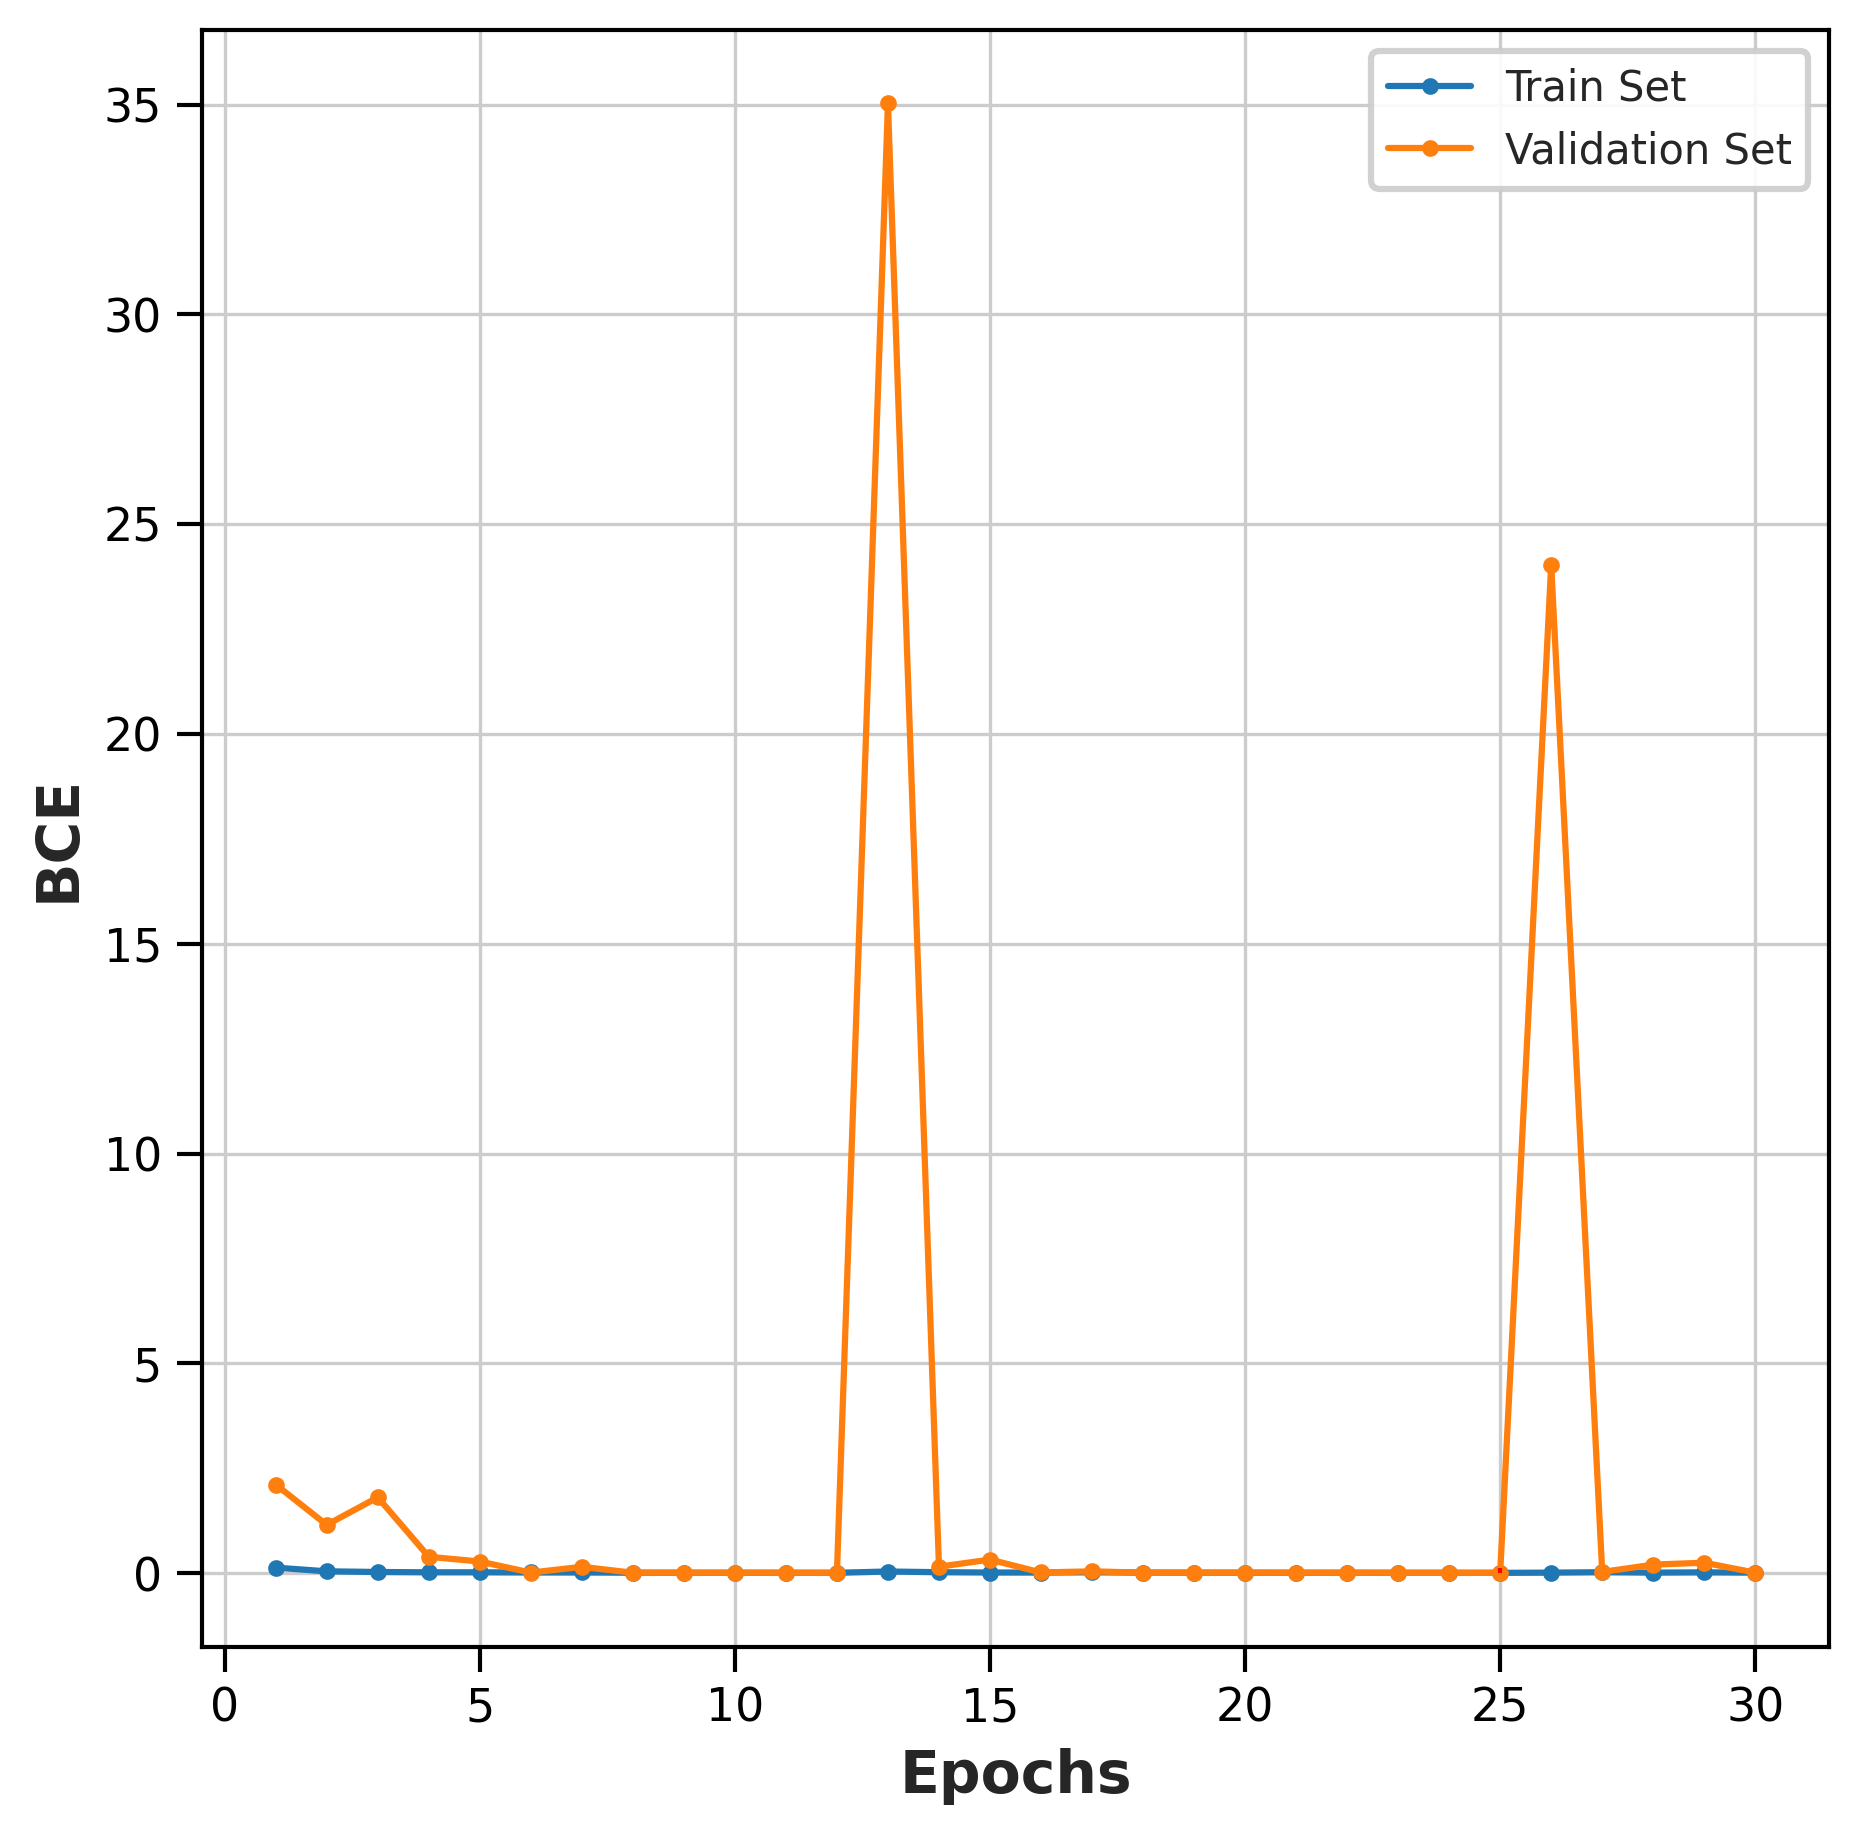

In [ ]:
plot_metric(model_trained, metric = 'loss', name = 'BCE', remark_best= True)

## Test Model

In [ ]:
model_CNN = keras.models.load_model(os.path.join(final_path, 'val_loss_min.keras'))

In [ ]:
score = model_CNN.evaluate(x = x_test, y = y_test)
score # score: 0.009146864525973797


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0091


0.009146864525973797

In [ ]:
preds = model_CNN.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [ ]:
i = np.random.randint(0, x_test.shape[0])
print( '{:.3f}'.format( float(preds[i])) )
plot_voxels(x_test[i])

0.000


/tmp/ipykernel_13852/2981139416.py:2: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

